# Problem Set 01 — Chest X-ray CNN
### Binary classification: NORMAL (0) versus PNEUMONIA (1)

This notebook contains the complete training and evaluation pipeline for the chest X-ray experiment. The model and reported metrics are generated from the dataset available at runtime; no pretrained model or fabricated result is included.

## Scope and execution order

The notebook is organized as a reproducible Colab workflow. It mounts the dataset, audits the images, creates a leakage-aware development split, trains a CNN from scratch, selects a validation threshold, and evaluates the frozen model once on the held-out test set. Problem Set 02 is outside the scope of this notebook.

The intended execution sequence is Steps 1–12, followed by Steps 13–16 after the model and threshold have been fixed. Step 17 is an optional demonstration of inference on an uploaded image. The dataset path is set in Step 3.

## Experimental conventions

- The original `test` directory remains untouched during training, model selection, and threshold selection.
- Class mapping is fixed throughout: `NORMAL = 0` and `PNEUMONIA = 1`. The sigmoid output is interpreted as a pneumonia score.
- The notebook reports the number of readable images found rather than assuming the count stated in the assignment.
- The result is an educational/research classifier. It is not a diagnosis, a calibrated clinical risk score, or a clinically approved system.
- Dataset-specific choices, experiments, and interpretations should be documented by the author of the submission. No accuracy is assumed in advance.

## Methodological overview

`Drive → local copy → image audit → leakage checks → grouped train/validation split`
`→ tf.data → from-scratch CNN → best validation checkpoint → validation threshold`
`→ frozen final test → reports and model artifacts`

The analysis follows these conventions:

- The assignment describes 5,863 images; the notebook records the number of readable images actually available in the supplied data.
- The original `train` and `val` directories form the development pool. A seed-fixed grouped split produces the working training and validation sets. The original validation split is therefore not treated as an independent estimate.
- Readable images from the original `test` directory remain held out. Duplicate test images are retained within the test set, while exact overlaps between test and development data are excluded from development.
- Exact duplicate detection uses SHA-256 hashes of decoded grayscale pixels. This does not guarantee detection of near-duplicates created by compression or resizing.
- Filename-derived `person...`, `IM-...`, and `NORMAL2-IM-...` patterns are treated only as conservative patient/study hints, not verified identifiers. Images without a usable hint are grouped by exact pixel hash.
- Development images sharing an exact hash or a filename-hint group with the test set are removed before splitting. The audit records every exclusion.
- Validation metrics are used for checkpoint and threshold selection; they are consequently not independent final estimates.

## Step 1 — Imports and runtime check

The pipeline uses the standard packages available in a Colab runtime. TensorFlow is not reinstalled by default. If a package is unavailable, the commented installation command can be run in a separate cell followed by a runtime restart.

A GPU is helpful for training speed but is not required for correctness.

In [ ]:
# Install only when the runtime is missing one or more required packages.
# %pip install tensorflow numpy pandas scikit-learn matplotlib Pillow tqdm

import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import io
import re
import sys
import json
import time
import shutil
import hashlib
import tempfile
import uuid
import zipfile
import platform
from pathlib import Path
from datetime import datetime, timezone
from concurrent.futures import ThreadPoolExecutor
from importlib.metadata import version, PackageNotFoundError

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
from IPython.display import display, Markdown

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, precision_recall_curve, roc_curve,
    ConfusionMatrixDisplay,
)

plt.style.use("seaborn-v0_8-whitegrid")
print("Python:", platform.python_version())
print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))
if not tf.config.list_physical_devices("GPU"):
    print("Runtime notice: no GPU is available; training will continue on CPU.")

## Step 2 — Mount Google Drive

This cell mounts Google Drive so that the source data and run artifacts can be read and persisted across Colab sessions. The authorization prompt is handled by Colab. Credentials and access tokens must not be stored in the notebook or repository.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## Step 3 — Configuration and dataset location

`DRIVE_DATASET_DIR` should point to a directory containing the following structure:

```text
MyDrive/Datasets/chest_xray/
├── train/
│   ├── NORMAL/
│   └── PNEUMONIA/
├── val/
│   ├── NORMAL/
│   └── PNEUMONIA/
└── test/
    ├── NORMAL/
    └── PNEUMONIA/
```

The root may be nested below the supplied path; the next cell searches a small number of levels and resolves a unique match. The configured path should refer to the dataset directory, rather than a ZIP archive, a split directory, or a class directory.

The default configuration uses 30 maximum epochs, a batch size of 32, and an image size of 180 × 180 pixels. Early stopping may terminate training earlier. If memory is insufficient, reducing the batch size is preferable to changing the split policy. Each execution creates a new output run directory.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from pathlib import Path
import json
import sys
import uuid
import platform
import os
from datetime import datetime, timezone
try:
    from importlib.metadata import version, PackageNotFoundError
except ImportError:
    from importlib_metadata import version, PackageNotFoundError

# Set this to the directory containing the unzipped dataset.
DRIVE_DATASET_DIR = Path("/content/drive/MyDrive/Datasets")

# Persist run artifacts on Drive; use temporary local storage for faster input reads.
DRIVE_OUTPUT_BASE = Path("/content/drive/MyDrive/problem01_outputs")
COPY_TO_LOCAL = True
LOCAL_WORK_DIR = Path("/content")

SEED = 42
IMAGE_SIZE = (180, 180)
CHANNELS = 1
BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 1e-3
FILTERS = (32, 64, 128, 256)
DENSE_UNITS = 128
DROPOUT = 0.40
L2_STRENGTH = 1e-4
N_SPLITS = 5  # First fixed stratified-group fold; this is not five-model cross-validation.
DATA_THREADS = 4
CLASS_NAMES = ["NORMAL", "PNEUMONIA"]
CLASS_TO_LABEL = {"NORMAL": 0, "PNEUMONIA": 1}
PIPELINE_VERSION = "1.0.0"

assert len(IMAGE_SIZE) == 2 and min(IMAGE_SIZE) >= 32
assert BATCH_SIZE > 0 and EPOCHS > 0 and N_SPLITS >= 2
assert CHANNELS == 1 and len(FILTERS) == 4

keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except (AttributeError, RuntimeError, NameError) as exc:
    print("Configuration notice:", type(exc).__name__)

RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ") + "_" + uuid.uuid4().hex[:6]
RUN_DIR = DRIVE_OUTPUT_BASE / RUN_ID
RESULTS_DIR = RUN_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = RUN_DIR / "best_cnn.keras"
INFERENCE_CONFIG_PATH = RUN_DIR / "inference_config.json"

run_config = {
    "pipeline_version": PIPELINE_VERSION, "run_id": RUN_ID, "seed": SEED,
    "image_size": list(IMAGE_SIZE), "channels": CHANNELS, "batch_size": BATCH_SIZE,
    "max_epochs": EPOCHS, "learning_rate": LEARNING_RATE, "filters": list(FILTERS),
    "dense_units": DENSE_UNITS, "dropout": DROPOUT, "l2": L2_STRENGTH,
    "split_policy": "pool_original_train_val_then_first_stratified_group_fold",
    "n_splits": N_SPLITS,
    "grouping_policy": "filename_hint_when_available_else_exact_pixel_hash",
    "test_overlap_policy": "exclude_development_hash_and_filename_hint_overlaps",
    "checkpoint_monitor": "val_pr_auc", "checkpoint_mode": "max",
    "threshold_policy": "max_validation_positive_class_f1_ties_choose_largest_threshold",
    "class_mapping": {"0": "NORMAL", "1": "PNEUMONIA"},
}
(RESULTS_DIR / "run_config.json").write_text(json.dumps(run_config, indent=2), encoding="utf-8")

environment = {"python": sys.version, "platform": platform.platform(), "tensorflow": tf.__version__}
for package in ["keras", "numpy", "pandas", "scikit-learn", "matplotlib", "Pillow", "tqdm"]:
    try:
        environment[package] = version(package)
    except (PackageNotFoundError, NameError, Exception):
        environment[package] = "not reported"
(RESULTS_DIR / "environment.json").write_text(json.dumps(environment, indent=2), encoding="utf-8")
print("Run ID:", RUN_ID)
print("Output directory:", RUN_DIR)

Run ID: 20260905T121522Z_f27df8
All saved outputs: /content/drive/MyDrive/problem01_outputs/20260905T121522Z_f27df8


## Step 4 — Resolve the dataset root and create a local copy

The source dataset on Drive is read-only from the perspective of this pipeline. When `COPY_TO_LOCAL=True`, only the `train`, `val`, and `test` directories are copied to temporary Colab storage to reduce per-batch Drive I/O. A new temporary copy is created for each run. Set `COPY_TO_LOCAL=False` when local disk space is limited, with the expected trade-off in training speed.

In [ ]:
import os
import shutil
import tempfile
from pathlib import Path
from tqdm.auto import tqdm

def is_dataset_root(path):
    path = Path(path)
    return all((path / split / cls).is_dir()
               for split in ("train", "val", "test") for cls in CLASS_NAMES)

def find_dataset_root(start, max_depth=3):
    start = Path(start).expanduser()
    if not start.is_dir():
        raise FileNotFoundError(
            f"Folder not found: {start}\nConfirm the Drive mount and the dataset path configured in Step 3."
        )
    if is_dataset_root(start):
        return start
    found = []
    for directory, dirs, _ in os.walk(start):
        current = Path(directory)
        depth = len(current.relative_to(start).parts)
        dirs[:] = [d for d in dirs if not d.startswith(".") and d != "__MACOSX"]
        if is_dataset_root(current):
            found.append(current)
            dirs[:] = []
        elif depth >= max_depth:
            dirs[:] = []
    if len(found) == 1:
        return found[0]
    if not found:
        children = sorted(p.name for p in start.iterdir())[:20]
        raise ValueError(
            "Expected train/val/test directories with NORMAL/PNEUMONIA subdirectories. "
            f"Root children: {children}. Set the inner dataset path in Step 3."
        )
    raise ValueError("Multiple dataset roots found; set the exact path in Step 3:\n" +
                     "\n".join(str(p) for p in found))

SOURCE_ROOT = find_dataset_root(DRIVE_DATASET_DIR)
print("Resolved dataset root:", SOURCE_ROOT)
if COPY_TO_LOCAL:
    LOCAL_WORK_DIR.mkdir(parents=True, exist_ok=True)
    DATA_ROOT = Path(tempfile.mkdtemp(prefix="problem01_data_", dir=str(LOCAL_WORK_DIR))) / "chest_xray"
    for split in tqdm(("train", "val", "test"), desc="Copying from Drive"):
        for cls in CLASS_NAMES:
            shutil.copytree(
                SOURCE_ROOT / split / cls, DATA_ROOT / split / cls,
                ignore=shutil.ignore_patterns(".*", "__MACOSX"),
            )
else:
    DATA_ROOT = SOURCE_ROOT
print("Reading images from:", DATA_ROOT)
print("Original Drive dataset was not modified.")

Resolved dataset root: /content/drive/MyDrive/Datasets


Copying from Drive:   0%|          | 0/3 [00:00<?, ?it/s]

Reading images from: /content/problem01_data_p6a6lsc9/chest_xray
Original Drive dataset was not modified.


## Step 5 — Image integrity, observed counts, and duplicate checks

The audit accepts JPEG and 8-bit PNG files while ignoring hidden files and `__MACOSX` entries. Unreadable or unsupported files are recorded and excluded from model inputs; their presence in the original test directory is still reflected in the audit outputs.

If identical decoded images appear with contradictory labels, the pipeline stops rather than resolving the conflict heuristically. The source data should be reviewed in that case.

This step reads every candidate image and may take several minutes. It performs no model training.

In [ ]:
import re
import hashlib
import pandas as pd
from PIL import Image
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
from tqdm.auto import tqdm
from IPython.display import display

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

def filename_proxy(path):
    """Unverified filename hints, never a claim of true patient identity."""
    stem = Path(path).stem.lower()
    match = re.match(r"^(person\d+)(?:_|$)", stem)
    if match:
        return "filename:" + match.group(1)
    match = re.match(r"^((?:normal\d+-)?im-\d+)-", stem)
    if match:
        return "filename:" + match.group(1)
    return None

def inspect_image(row):
    try:
        with Image.open(row["filepath"]) as image:
            image.load()
            if image.format not in {"JPEG", "PNG"}:
                raise ValueError("Expected JPEG or PNG")
            if image.mode in {"I", "F", "I;16", "I;16B", "I;16L"}:
                raise ValueError("Expected 8-bit input")
            gray = image.convert("L")
            width, height = gray.size
            if min(width, height) < 16:
                raise ValueError("Image too small")
            digest = hashlib.sha256()
            digest.update(f"L:{width}:{height}:".encode("utf-8"))
            digest.update(gray.tobytes())
        proxy = filename_proxy(row["filepath"])
        return {
            **row, "readable": True, "width": width, "height": height,
            "pixel_sha256": digest.hexdigest(), "patient_proxy": proxy,
            "group_id": proxy if proxy else "image:" + digest.hexdigest(),
            "group_source": "filename_hint" if proxy else "image_hash_only", "error": "",
        }
    except Exception as exc:
        return {**row, "readable": False,
                "error": f"{type(exc).__name__}: unreadable/unsupported image"}

candidates = []
for split in ("train", "val", "test"):
    for cls in CLASS_NAMES:
        class_dir = DATA_ROOT / split / cls
        if not class_dir.exists(): continue
        for path in sorted(class_dir.rglob("*")):
            if not path.is_file() or path.suffix.lower() not in IMAGE_EXTENSIONS:
                continue
            rel = path.relative_to(DATA_ROOT)
            if any(part.startswith(".") or part == "__MACOSX" for part in rel.parts):
                continue
            candidates.append({
                "filepath": str(path), "relative_path": rel.as_posix(),
                "original_split": split, "class_name": cls, "label": CLASS_TO_LABEL[cls],
            })

if not candidates:
    raise ValueError("No JPEG/PNG candidates found. Check the dataset path and folder structure.")

with ThreadPoolExecutor(max_workers=DATA_THREADS) as pool:
    inspected = list(tqdm(pool.map(inspect_image, candidates), total=len(candidates), desc="Image audit"))

all_audited = pd.DataFrame(inspected)
invalid_df = all_audited.loc[~all_audited["readable"]].copy()
invalid_df.drop(columns=["filepath"], errors="ignore").to_csv(RESULTS_DIR / "invalid_images.csv", index=False)
valid_df = all_audited.loc[all_audited["readable"]].copy().reset_index(drop=True)

if valid_df.empty:
    raise ValueError("No readable supported images remain. Inspect invalid_images.csv.")

valid_df["label"] = valid_df["label"].astype(int)
valid_df[["width", "height"]] = valid_df[["width", "height"]].astype(int)

original_counts = pd.crosstab(valid_df["original_split"], valid_df["class_name"]).reindex(
    index=["train", "val", "test"], columns=CLASS_NAMES, fill_value=0
).fillna(0).astype(int)
original_counts["TOTAL"] = original_counts.sum(axis=1)
original_counts.to_csv(RESULTS_DIR / "original_counts.csv")

print("Assignment description: 5,863 images.")
print(f"Candidates: {len(candidates)} | Readable: {len(valid_df)} | Excluded: {len(invalid_df)}")
display(original_counts)

hash_label_counts = valid_df.groupby("pixel_sha256")["label"].nunique()
conflict_hashes = set(hash_label_counts[hash_label_counts > 1].index)
if conflict_hashes:
    conflicts = valid_df[valid_df["pixel_sha256"].isin(conflict_hashes)].drop(columns="filepath")
    conflicts.to_csv(RESULTS_DIR / "label_conflicts.csv", index=False)
    raise ValueError("Identical images have contradictory labels. Inspect label_conflicts.csv.")

print("Repeated-image excess:", int(valid_df.duplicated("pixel_sha256").sum()))

Image audit:   0%|          | 0/5856 [00:00<?, ?it/s]

Assignment description: 5,863 images.
Candidates: 5856 | Readable: 5856 | Excluded: 0


class_name,NORMAL,PNEUMONIA,TOTAL
original_split,,,
train,1341,3875,5216
val,8,8,16
test,234,390,624


Repeated-image excess: 32


## Step 6 — Development cleaning and grouped validation split

The original test set is retained as a held-out evaluation set. The original `train` and `val` data are combined into a development pool, after which the pipeline:

1. removes development images with exact pixel matches or filename-hint groups also present in test;
2. retains one copy of each repeated decoded image within development data;
3. creates a seed-fixed, stratified grouped split using the first fold of `StratifiedGroupKFold`; and
4. computes class weights from the resulting training partition only.

This is a single train/validation split, not five-model cross-validation. Filename patterns are conservative and unverified patient/study hints, so they may exclude unrelated files while still failing to establish true patient-level independence. The audit records the effect of these assumptions.

In [ ]:
MANIFEST_COLUMNS = [
    "relative_path", "original_split", "class_name", "label", "width", "height",
    "pixel_sha256", "patient_proxy", "group_id", "group_source",
]

test_df = valid_df[valid_df["original_split"] == "test"].sort_values("relative_path").reset_index(drop=True)
dev = valid_df[valid_df["original_split"].isin(["train", "val"])].sort_values("relative_path").copy()
original_dev_count = len(dev)
removed_parts = []

test_hashes = set(test_df["pixel_sha256"])
mask = dev["pixel_sha256"].isin(test_hashes)
removed_parts.append(dev.loc[mask].assign(exclusion_reason="exact_pixels_also_in_original_test"))
dev = dev.loc[~mask].copy()

test_hint_groups = set(test_df.loc[test_df["group_source"] == "filename_hint", "group_id"])
mask = dev["group_id"].isin(test_hint_groups)
removed_parts.append(dev.loc[mask].assign(exclusion_reason="filename_hint_group_also_in_original_test"))
dev = dev.loc[~mask].copy()

mask = dev.duplicated("pixel_sha256", keep="first")
removed_parts.append(dev.loc[mask].assign(exclusion_reason="duplicate_pixels_within_development"))
dev = dev.loc[~mask].reset_index(drop=True)
excluded_dev = pd.concat(removed_parts, ignore_index=True)
excluded_dev[MANIFEST_COLUMNS + ["exclusion_reason"]].to_csv(RESULTS_DIR / "excluded_development.csv", index=False)

if set(dev["label"].unique()) != {0, 1}:
    raise ValueError("Cleaning removed an entire class. Review filename hints/source data.")

class_group_counts = dev.groupby("label")["group_id"].nunique()
if (class_group_counts < N_SPLITS).any():
    raise ValueError(f"Too few distinct groups per class for {N_SPLITS} folds: {class_group_counts.to_dict()}")

from sklearn.model_selection import StratifiedGroupKFold

splitter = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
train_idx, val_idx = next(splitter.split(dev, y=dev["label"], groups=dev["group_id"]))
train_df = dev.iloc[train_idx].sort_values("relative_path").reset_index(drop=True)
val_df = dev.iloc[val_idx].sort_values("relative_path").reset_index(drop=True)

for split_name, frame in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    frame[MANIFEST_COLUMNS].to_csv(RESULTS_DIR / f"manifest_{split_name}.csv", index=False)

def manifest_fingerprint(frame):
    content = frame[MANIFEST_COLUMNS].sort_values("relative_path").to_csv(index=False)
    return hashlib.sha256(content.encode("utf-8")).hexdigest()

audit_summary = {
    "candidate_images": len(candidates), "readable_images": len(valid_df),
    "invalid_images": len(invalid_df),
    "original_development_images": original_dev_count,
    "clean_development_images": len(dev),
    "excluded_development_images": len(excluded_dev),
    "exclusions_by_reason": {str(k): int(v) for k, v in excluded_dev["exclusion_reason"].value_counts().items()},
    "readable_test_images_retained": len(test_df),
    "validation_fraction_of_clean_development": len(val_df) / len(dev),
    "manifest_sha256": {name: manifest_fingerprint(frame) for name, frame in
                         [("train", train_df), ("validation", val_df), ("test", test_df)]},
}
(RESULTS_DIR / "dataset_audit.json").write_text(json.dumps(audit_summary, indent=2), encoding="utf-8")

final_counts = pd.DataFrame({
    name: frame["class_name"].value_counts().reindex(CLASS_NAMES, fill_value=0)
    for name, frame in [("train", train_df), ("validation", val_df), ("test", test_df)]
}).T.astype(int)
final_counts["TOTAL"] = final_counts.sum(axis=1)

print("Development rows removed:", len(excluded_dev))
print("Removal reasons:", audit_summary["exclusions_by_reason"])
print(f"Validation fraction: {len(val_df) / len(dev):.1%}")
display(final_counts)

Development rows removed: 479
Removal reasons: {'filename_hint_group_also_in_original_test': 457, 'duplicate_pixels_within_development': 22}
Validation fraction: 19.7%


class_name,NORMAL,PNEUMONIA,TOTAL
train,1078,2737,3815
validation,270,668,938
test,234,390,624


## Step 7 — Exploratory data review

This review summarizes the final class counts and the original image dimensions, then displays a small set of training examples. Test labels and test errors are intentionally absent from this stage. The plots provide basic checks for class imbalance, image decoding, and label-to-folder consistency; they are not clinical interpretations.

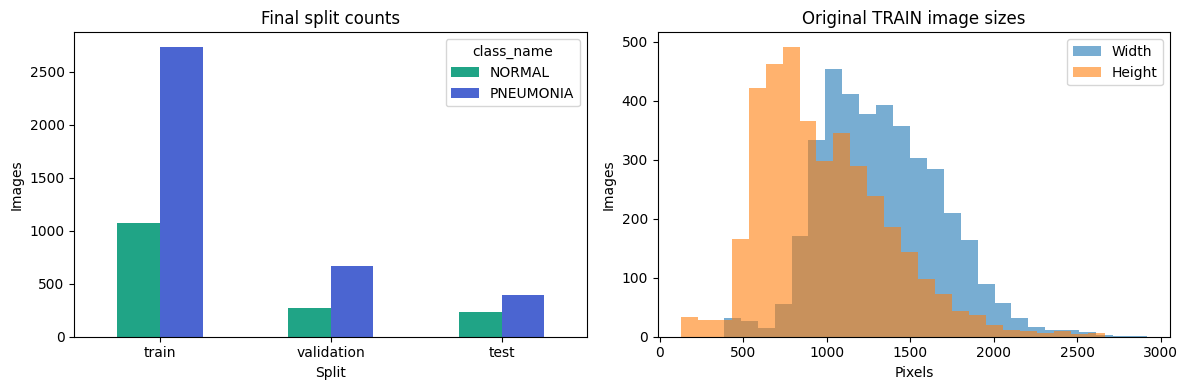

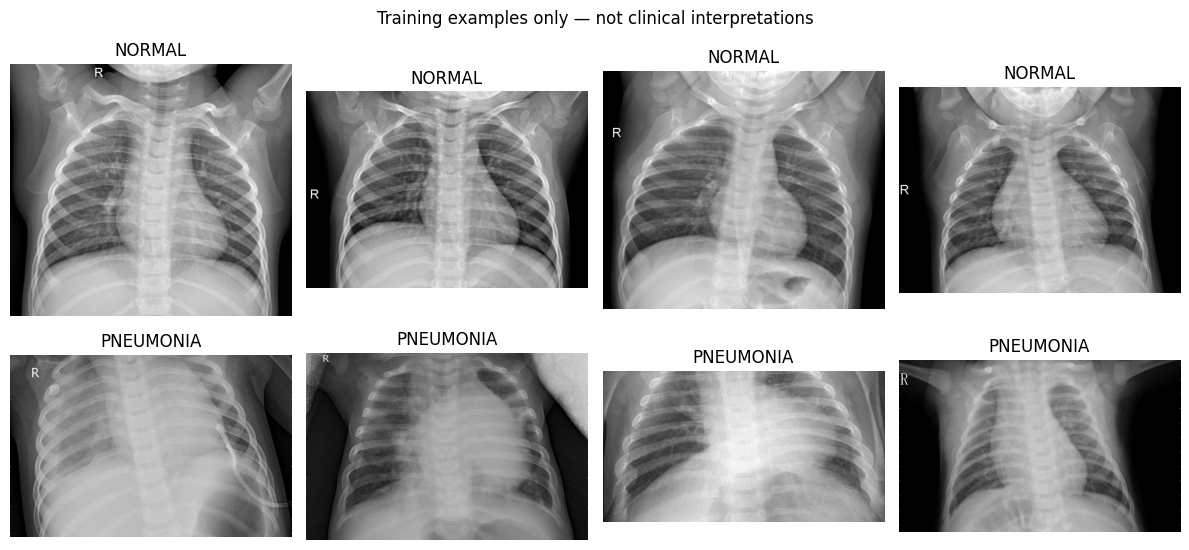

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
final_counts[CLASS_NAMES].plot.bar(ax=axes[0], color=["#20a486", "#4b65d1"], rot=0)
axes[0].set(title="Final split counts", ylabel="Images", xlabel="Split")
axes[1].hist(train_df["width"], bins=25, alpha=0.6, label="Width")
axes[1].hist(train_df["height"], bins=25, alpha=0.6, label="Height")
axes[1].set(title="Original TRAIN image sizes", xlabel="Pixels", ylabel="Images")
axes[1].legend()
fig.tight_layout()
fig.savefig(RESULTS_DIR / "data_overview.png", dpi=160, bbox_inches="tight")
plt.show()
plt.close(fig)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for row_idx, cls in enumerate(CLASS_NAMES):
    subset = train_df[train_df["class_name" ] == cls]
    samples = subset.sample(n=min(4, len(subset)), random_state=SEED)
    for ax in axes[row_idx]:
        ax.axis("off")
    for col_idx, record in enumerate(samples.itertuples()):
        with Image.open(record.filepath) as img:
            axes[row_idx, col_idx].imshow(img.convert("L"), cmap="gray")
        axes[row_idx, col_idx].set_title(cls)
fig.suptitle("Training examples only — not clinical interpretations")
fig.tight_layout()
plt.show()
plt.close(fig)

## Step 8 — `tf.data` input pipeline and class weights

The input pipeline converts images to one-channel tensors, resizes them to the configured dimensions using bilinear interpolation with antialiasing, and keeps pixel values in the float32 range 0–255. Normalization is performed once inside the model through `Rescaling(1/255)`.

Training data are shuffled; validation data retain a deterministic order so that predictions remain aligned with their labels. The full decoded dataset is not cached in RAM. Class weights use only the training partition and follow $w_c = N / (2n_c)$, where $n_c$ is the training count for class $c$.

In [ ]:
import numpy as np
import tensorflow as tf
import json

def decode_and_resize(path, label):
    image = tf.io.decode_image(tf.io.read_file(path), channels=CHANNELS, expand_animations=False)
    image.set_shape([None, None, CHANNELS])
    image = tf.image.resize(image, IMAGE_SIZE, method="bilinear", antialias=True)
    image = tf.cast(image, tf.float32)
    return image, tf.reshape(tf.cast(label, tf.float32), [1])

def make_dataset(frame, training=False):
    paths = frame["filepath"].astype(str).to_numpy()
    labels = frame["label"].to_numpy(dtype=np.float32)
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        dataset = dataset.shuffle(len(frame), seed=SEED, reshuffle_each_iteration=True)
    dataset = dataset.map(decode_and_resize, num_parallel_calls=tf.data.AUTOTUNE, deterministic=True)
    dataset = dataset.batch(BATCH_SIZE, drop_remainder=False).prefetch(2)
    options = tf.data.Options()
    options.experimental_deterministic = True
    options.threading.private_threadpool_size = DATA_THREADS
    return dataset.with_options(options)

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)

train_label_counts = train_df["label"].value_counts().to_dict()
class_weight = {label: len(train_df) / (2.0 * train_label_counts[label]) for label in [0, 1]}
(RESULTS_DIR / "class_weights.json").write_text(json.dumps(class_weight, indent=2), encoding="utf-8")
print("Dataset specification:", train_ds.element_spec)
print("Training counts:", train_label_counts)
print("Class weights:", class_weight)

Dataset specification: (TensorSpec(shape=(None, 180, 180, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))
Training counts: {1: 2737, 0: 1078}
Class weights: {0: 1.7694805194805194, 1: 0.69693094629156}


## Step 9 — CNN trained from scratch

The model follows the sequence:

`Input → rescaling → training-only augmentation → four convolutional blocks → global average pooling → dense layer → dropout → sigmoid output`

Each convolutional block contains two `Conv2D + BatchNormalization + ReLU` units followed by max pooling. Global average pooling limits the number of parameters, while L2 regularization and dropout provide additional controls against overfitting. These choices are intended to regularize the experiment; they do not guarantee improved performance.

Augmentation is limited to small rotations, translations, and zooms. Horizontal and vertical flips are omitted to avoid altering potentially meaningful anatomical orientation. The model is optimized with binary cross-entropy and Adam. The checkpoint metric is Keras' interpolated validation PR-AUC. The final report also includes scikit-learn Average Precision, which uses a different definition and should not be treated as the same quantity.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

keras.backend.clear_session()
keras.utils.set_random_seed(SEED)

augmentation = keras.Sequential([
    layers.RandomRotation(0.025, fill_mode="reflect", seed=SEED + 1),
    layers.RandomTranslation(0.03, 0.03, fill_mode="reflect", seed=SEED + 2),
    layers.RandomZoom(height_factor=(-0.05, 0.05), width_factor=(-0.05, 0.05),
                      fill_mode="reflect", seed=SEED + 3),
], name="training_only_augmentation")

inputs = keras.Input(shape=(*IMAGE_SIZE, CHANNELS), name="grayscale_xray_0_to_255")
x = layers.Rescaling(1.0 / 255.0, name="normalize_0_to_1")(inputs)
x = augmentation(x)
for block, filters in enumerate(FILTERS, start=1):
    for conv in (1, 2):
        x = layers.Conv2D(
            filters, 3, padding="same", use_bias=False, kernel_initializer="he_normal",
            kernel_regularizer=regularizers.l2(L2_STRENGTH), name=f"block{block}_conv{conv}",
        )(x)
        x = layers.BatchNormalization(name=f"block{block}_bn{conv}")(x)
        x = layers.Activation("relu", name=f"block{block}_relu{conv}")(x)
    x = layers.MaxPooling2D(2, name=f"block{block}_pool")(x)

x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
x = layers.Dense(DENSE_UNITS, activation="relu", kernel_regularizer=regularizers.l2(L2_STRENGTH), name="dense_features")(x)
x = layers.Dropout(DROPOUT, seed=SEED + 4, name="dropout")(x)
outputs = layers.Dense(1, activation="sigmoid", dtype="float32", name="pneumonia_score")(x)
model = keras.Model(inputs, outputs, name="chest_xray_cnn_from_scratch")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy", threshold=0.5),
        keras.metrics.Precision(name="precision", thresholds=0.5),
        keras.metrics.Recall(name="recall", thresholds=0.5),
        keras.metrics.AUC(name="roc_auc", curve="ROC"),
        keras.metrics.AUC(name="pr_auc", curve="PR"),
    ],
    jit_compile=False
)
model.summary()

Model: "chest_xray_cnn_from_scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ grayscale_xray_0_to_255         │ (None, 180, 180, 1)    │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalize_0_to_1 (Rescaling)    │ (None, 180, 180, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ training_only_augmentation      │ (None, 180, 180, 1)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 180, 180, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn1 (BatchNormalization) │ (None, 180, 180, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu1 (Activation)       │ (None, 180, 180, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 180, 180, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn2 (BatchNormalization) │ (None, 180, 180, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu2 (Activation)       │ (None, 180, 180, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 90, 90, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn1 (BatchNormalization) │ (None, 90, 90, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu1 (Activation)       │ (None, 90, 90, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 90, 90, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn2 (BatchNormalization) │ (None, 90, 90, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu2 (Activation)       │ (None, 90, 90, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 45, 45, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn1 (BatchNormalization) │ (None, 45, 45, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu1 (Activation)       │ (None, 45, 45, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 45, 45, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn2 (BatchNormalization) │ (None, 45, 45, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu2 (Activation)       │ (None, 45, 45, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 22, 22, 128)    │             

 Total params: 1,207,585 (4.61 MB)

 Trainable params: 1,205,665 (4.60 MB)

 Non-trainable params: 1,920 (7.50 KB)

## Step 10 — Model training

This cell trains the CNN and records the epoch history and selected checkpoint in the run directory. Runtime depends on the available hardware and Colab session.

- `ModelCheckpoint` retains the weights with the highest validation PR-AUC.
- `EarlyStopping` restores those weights after six epochs without improvement.
- `ReduceLROnPlateau` lowers the learning rate when validation progress stalls.
- `CSVLogger` stores the epoch-level history.

Class weights affect the training loss, and augmentation is active only during training. Consequently, the absolute train and validation loss values are not directly comparable as measurements from identical data-generating conditions. The reported accuracy, precision, recall, and related metrics remain unweighted.

In [ ]:
import time
import numpy as np
import pandas as pd
import json

callbacks = [
    keras.callbacks.ModelCheckpoint(
        str(MODEL_PATH), monitor="val_pr_auc", mode="max", save_best_only=True, verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_pr_auc", mode="max", patience=6, min_delta=0.0,
        restore_best_weights=True, verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_pr_auc", mode="max", factor=0.5, patience=2,
        cooldown=1, min_delta=1e-4, min_lr=1e-6, verbose=1,
    ),
    keras.callbacks.CSVLogger(str(RESULTS_DIR / "history.csv")),
    keras.callbacks.TerminateOnNaN(),
]

started_at = time.perf_counter()
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1,
)
training_seconds = time.perf_counter() - started_at
history_df = pd.DataFrame(history.history)
history_df.insert(0, "epoch", np.arange(1, len(history_df) + 1))
history_df.to_csv(RESULTS_DIR / "history.csv", index=False)

best_epoch = int(history_df.loc[history_df["val_pr_auc"].idxmax(), "epoch"])
training_info = {
    "epochs_completed": len(history_df), "best_epoch_one_based": best_epoch,
    "best_validation_keras_pr_auc": float(history_df["val_pr_auc"].max()),
    "training_seconds": float(training_seconds), "parameter_count": int(model.count_params()),
}
(RESULTS_DIR / "training_info.json").write_text(json.dumps(training_info, indent=2), encoding="utf-8")
print(f"Training finished: {len(history_df)} epochs, {training_seconds / 60:.1f} minutes")

Epoch 1/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.8450 - loss: 0.5539 - pr_auc: 0.9654 - precision: 0.9511 - recall: 0.8199 - roc_auc: 0.9211
Epoch 1: val_pr_auc improved from None to 0.95963, saving model to /content/drive/MyDrive/problem01_outputs/20260905T121522Z_f27df8/best_cnn.keras

Epoch 1: finished saving model to /content/drive/MyDrive/problem01_outputs/20260905T121522Z_f27df8/best_cnn.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 57s 354ms/step - accuracy: 0.8776 - loss: 0.4929 - pr_auc: 0.9786 - precision: 0.9629 - recall: 0.8626 - roc_auc: 0.9476 - val_accuracy: 0.7175 - val_loss: 1.0353 - val_pr_auc: 0.9596 - val_precision: 0.7169 - val_recall: 0.9970 - val_roc_auc: 0.9045 - learning_rate: 0.0010
Epoch 2/30
119/120 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - accuracy: 0.9296 - loss: 0.3727 - pr_auc: 0.9920 - precision: 0.9736 - recall: 0.9269 - roc_auc: 0.9796
Epoch 2: val_pr_auc improved from 0.95963 to 0.98143, saving model to /content/drive/MyDrive/problem01_outputs/202

## Step 11 — Learning curves

The plots compare training and validation trajectories for loss, accuracy, recall, and PR-AUC. They support a qualitative assessment of optimization and possible overfitting, but no single curve is sufficient for that conclusion. Class balance, sample size, augmentation, weighted loss, and the validation split are considered alongside the curves.

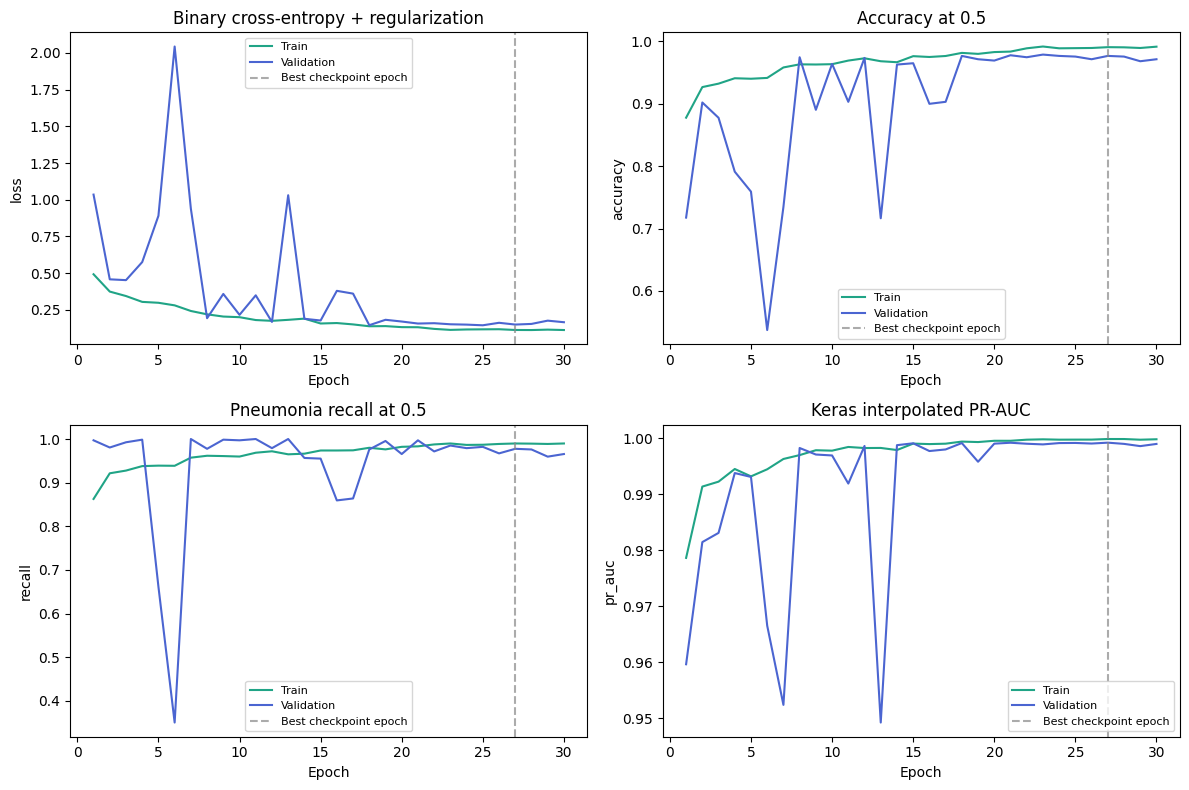

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, metric, title in zip(
    axes.flat, ["loss", "accuracy", "recall", "pr_auc"],
    ["Binary cross-entropy + regularization", "Accuracy at 0.5", "Pneumonia recall at 0.5", "Keras interpolated PR-AUC"],
):
    ax.plot(history_df["epoch"], history_df[metric], label="Train", color="#20a486")
    ax.plot(history_df["epoch"], history_df["val_" + metric], label="Validation", color="#4b65d1")
    ax.axvline(best_epoch, color="#888888", ls="--", alpha=0.7, label="Best checkpoint epoch")
    ax.set(title=title, xlabel="Epoch", ylabel=metric)
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "training_curves.png", dpi=160, bbox_inches="tight")
plt.show()
plt.close(fig)

## Step 12 — Freeze the best checkpoint and validation threshold

The notebook reports both the default threshold of 0.5 and a threshold selected by maximizing positive-class F1 on the validation set. Ties are resolved by choosing the larger threshold. This is an explicit experimental rule, not a claim that F1 maximization is clinically optimal.

Because the model uses class weighting and the data come from a single source, the sigmoid output should not automatically be interpreted as a calibrated disease probability. It is used here as a model score for thresholding, not as a clinical risk estimate.

At the end of this step, the model hash, preprocessing specification, class mapping, and selected threshold are saved together. Further model comparisons should use validation data only; the held-out test set remains untouched until the final configuration is fixed.

30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 232ms/step


,rule,threshold,accuracy,precision,recall_sensitivity,specificity,f1,roc_auc,average_precision
0,fixed_0.5,0.500000,0.976546,0.989394,0.977545,0.974074,0.983434,0.997971,0.999187
1,validation_F1_selected,0.269003,0.980810,0.986527,0.986527,0.966667,0.986527,0.997971,0.999187


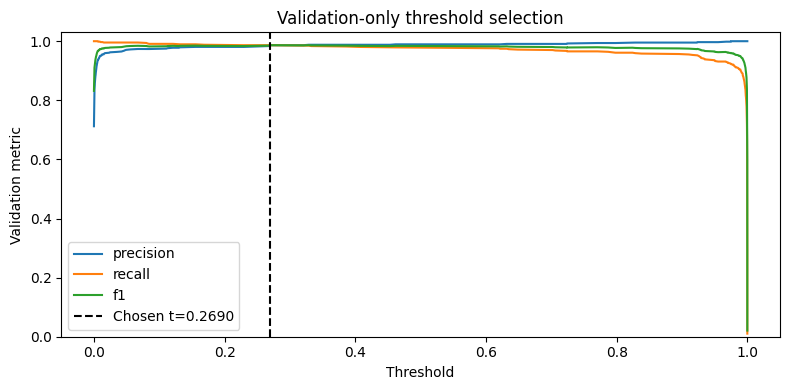

Frozen model: /content/drive/MyDrive/problem01_outputs/20260905T121522Z_f27df8/best_cnn.keras
Frozen threshold: 0.26900339126586914
Saved preprocessing + class mapping + threshold: /content/drive/MyDrive/problem01_outputs/20260905T121522Z_f27df8/inference_config.json
Training + validation complete. Final test has NOT been evaluated yet.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import hashlib
from pathlib import Path
from datetime import datetime, timezone
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score, confusion_matrix,
    precision_recall_curve
)

def file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def binary_metrics(y_true, scores, threshold):
    y_true = np.asarray(y_true, dtype=int).reshape(-1)
    scores = np.asarray(scores, dtype=float).reshape(-1)
    if len(y_true) != len(scores) or not np.isfinite(scores).all():
        raise ValueError("Invalid score length or non-finite predictions.")
    if set(np.unique(y_true)) != {0, 1}:
        raise ValueError("Both true classes are needed for these ROC/AP reports.")
    y_pred = (scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "n": int(len(y_true)), "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall_sensitivity": float(recall_score(y_true, y_pred, zero_division=0)),
        "specificity": float(tn / (tn + fp)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, scores)),
        "average_precision": float(average_precision_score(y_true, scores)),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }

best_model = keras.models.load_model(MODEL_PATH, compile=False)
y_val = val_df["label"].to_numpy(dtype=int)
val_scores = best_model.predict(val_ds, verbose=1).reshape(-1)
assert len(val_scores) == len(val_df) and np.isfinite(val_scores).all()

v_precision, v_recall, v_thresholds = precision_recall_curve(y_val, val_scores)
v_f1 = 2 * v_precision[:-1] * v_recall[:-1] / np.maximum(v_precision[:-1] + v_recall[:-1], 1e-12)
best_indices = np.flatnonzero(v_f1 >= np.max(v_f1) - 1e-12)
chosen_idx = int(best_indices[-1])
chosen_threshold = float(v_thresholds[chosen_idx])
val_default = binary_metrics(y_val, val_scores, 0.5)
val_selected = binary_metrics(y_val, val_scores, chosen_threshold)

threshold_table = pd.DataFrame({"threshold": v_thresholds, "precision": v_precision[:-1],
                                "recall": v_recall[:-1], "f1": v_f1})
threshold_table.to_csv(RESULTS_DIR / "validation_threshold_search.csv", index=False)
val_prediction_table = val_df[MANIFEST_COLUMNS].copy()
val_prediction_table["pneumonia_score"] = val_scores
val_prediction_table["pred_default_0_5"] = (val_scores >= 0.5).astype(int)
val_prediction_table["pred_selected"] = (val_scores >= chosen_threshold).astype(int)
val_prediction_table.to_csv(RESULTS_DIR / "validation_predictions.csv", index=False)
validation_metrics_df = pd.DataFrame([{"rule": "fixed_0.5", **val_default},
                                      {"rule": "validation_F1_selected", **val_selected}])
validation_metrics_df.to_csv(RESULTS_DIR / "validation_metrics.csv", index=False)
display(validation_metrics_df[["rule", "threshold", "accuracy", "precision", "recall_sensitivity", "specificity", "f1", "roc_auc", "average_precision"]])

fig, ax = plt.subplots(figsize=(8, 4))
for metric in ["precision", "recall", "f1"]:
    ax.plot(threshold_table["threshold"], threshold_table[metric], label=metric)
ax.axvline(chosen_threshold, color="black", ls="--", label=f"Chosen t={chosen_threshold:.4f}")
ax.set(xlabel="Threshold", ylabel="Validation metric", title="Validation-only threshold selection", ylim=(0, 1.03))
ax.legend()
fig.tight_layout()
fig.savefig(RESULTS_DIR / "validation_threshold.png", dpi=160, bbox_inches="tight")
plt.show()
plt.close(fig)

inference_config = {
    "pipeline_version": PIPELINE_VERSION, "run_id": RUN_ID,
    "image_size": list(IMAGE_SIZE), "channels": 1,
    "decoder": "tf.io.decode_image(channels=1, expand_animations=False)",
    "resize": "bilinear with antialias=True",
    "input_range": "float32 pixels in 0..255; do NOT divide by 255 outside the model",
    "normalization": "Rescaling(1/255) is included in the saved model",
    "class_mapping": {"0": "NORMAL", "1": "PNEUMONIA"},
    "positive_class": "PNEUMONIA", "threshold": chosen_threshold,
    "threshold_source": "validation set only; maximize positive-class F1; ties choose largest threshold",
    "checkpoint_selection": "maximum validation Keras interpolated PR-AUC",
    "best_epoch_one_based": best_epoch,
    "model_sha256": file_sha256(MODEL_PATH),
    "manifest_sha256": audit_summary["manifest_sha256"],
    "frozen_at_utc": datetime.now(timezone.utc).isoformat(),
    "not_for_clinical_use": True,
}
INFERENCE_CONFIG_PATH.write_text(json.dumps(inference_config, indent=2), encoding="utf-8")
print("Frozen model:", MODEL_PATH)
print("Frozen threshold:", chosen_threshold)
print("Saved preprocessing + class mapping + threshold:", INFERENCE_CONFIG_PATH)
print("Training + validation complete. Final test has NOT been evaluated yet.")

## Step 13 — Final test evaluation after model selection

`RUN_FINAL_TEST` is an intentional gate. When it is `False`, the held-out test set and final reporting cells are skipped while the training and validation artifacts remain available.

The test set should be evaluated only after the architecture, checkpoint, and threshold have been fixed. Repeatedly selecting a model by its score on the same test set would turn that set into tuning data and invalidate the final estimate. This cell therefore reports both the fixed 0.5 threshold and the threshold selected on validation. The majority-class baseline is derived from the training partition.

In [ ]:
import numpy as np
import pandas as pd
import json
import hashlib
from pathlib import Path
from datetime import datetime, timezone
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report

def file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

RUN_FINAL_TEST = True  # Evaluate the frozen model on the held-out test set when enabled.

if not RUN_FINAL_TEST:
    print("Final test evaluation skipped; the frozen model and validation artifacts remain available.")
else:
    frozen_config = json.loads(INFERENCE_CONFIG_PATH.read_text(encoding="utf-8"))
    assert file_sha256(MODEL_PATH) == frozen_config["model_sha256"], "Checkpoint changed after freezing."
    assert manifest_fingerprint(test_df) == frozen_config["manifest_sha256"]["test"], "Test manifest changed."
    chosen_threshold = float(frozen_config["threshold"])
    final_model = keras.models.load_model(MODEL_PATH, compile=False)
    test_ds = make_dataset(test_df, training=False)
    y_test = test_df["label"].to_numpy(dtype=int)
    test_scores = final_model.predict(test_ds, verbose=1).reshape(-1)
    assert len(test_scores) == len(test_df) and np.isfinite(test_scores).all()

    test_default = binary_metrics(y_test, test_scores, 0.5)
    test_selected = binary_metrics(y_test, test_scores, chosen_threshold)
    majority_label = int(train_df["label"].value_counts().idxmax())
    majority_scores = np.full(len(y_test), float(majority_label))
    majority_metrics = binary_metrics(y_test, majority_scores, 0.5)

    test_metrics_df = pd.DataFrame([
        {"model_rule": "CNN_fixed_0.5", **test_default},
        {"model_rule": "CNN_validation_F1_threshold", **test_selected},
        {"model_rule": f"majority_baseline_{CLASS_NAMES[majority_label]}", **majority_metrics},
    ])
    test_metrics_df.to_csv(RESULTS_DIR / "test_metrics.csv", index=False)
    display(test_metrics_df[["model_rule", "threshold", "accuracy", "balanced_accuracy", "precision", "recall_sensitivity", "specificity", "f1", "roc_auc", "average_precision"]])

    test_prediction_table = test_df[MANIFEST_COLUMNS].copy()
    test_prediction_table["pneumonia_score"] = test_scores
    test_prediction_table["pred_default_0_5"] = (test_scores >= 0.5).astype(int)
    test_prediction_table["pred_selected"] = (test_scores >= chosen_threshold).astype(int)
    test_prediction_table.to_csv(RESULTS_DIR / "test_predictions.csv", index=False)
    errors = test_prediction_table[test_prediction_table["label"] != test_prediction_table["pred_selected"]].copy()
    errors["error_type"] = np.where(errors["label"] == 1, "false_negative_pneumonia_missed", "false_positive_normal_flagged")
    errors.to_csv(RESULTS_DIR / "misclassified_test.csv", index=False)

    report_dict = classification_report(
        y_test, test_prediction_table["pred_selected"], labels=[0, 1],
        target_names=CLASS_NAMES, digits=4, zero_division=0, output_dict=True,
    )
    report_text = classification_report(
        y_test, test_prediction_table["pred_selected"], labels=[0, 1], digits=4, zero_division=0,
        target_names=CLASS_NAMES,
    )
    (RESULTS_DIR / "classification_report.txt").write_text(report_text, encoding="utf-8")
    (RESULTS_DIR / "classification_report.json").write_text(json.dumps(report_dict, indent=2), encoding="utf-8")
    metrics_bundle = {
        "run_id": RUN_ID, "positive_class": "PNEUMONIA", "selected_threshold": chosen_threshold,
        "validation_fixed_0_5": val_default, "validation_selected": val_selected,
        "test_fixed_0_5": test_default, "test_selected": test_selected,
        "majority_baseline_class_from_training": CLASS_NAMES[majority_label],
        "test_majority_baseline": majority_metrics,
        "test_evaluated_at_utc": datetime.now(timezone.utc).isoformat(),
        "model_sha256": frozen_config["model_sha256"],
    }
    (RESULTS_DIR / "metrics.json").write_text(json.dumps(metrics_bundle, indent=2, allow_nan=False), encoding="utf-8")
    print("Classification report at validation-selected threshold:")
    print(report_text)
    print("Headline precision/recall/F1 metrics use PNEUMONIA as the positive class.")
    print("Final test artifacts:", RESULTS_DIR)

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 278ms/step


,model_rule,threshold,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,f1,roc_auc,average_precision
0,CNN_fixed_0.5,0.500000,0.828526,0.772222,0.785859,0.997436,0.547009,0.879096,0.95235,0.957574
1,CNN_validation_F1_threshold,0.269003,0.804487,0.739316,0.761719,1.000000,0.478632,0.864745,0.95235,0.957574
2,majority_baseline_PNEUMONIA,0.500000,0.625000,0.500000,0.625000,1.000000,0.000000,0.769231,0.50000,0.625000


Classification report at validation-chosen threshold:
              precision    recall  f1-score   support

      NORMAL     1.0000    0.4786    0.6474       234
   PNEUMONIA     0.7617    1.0000    0.8647       390

    accuracy                         0.8045       624
   macro avg     0.8809    0.7393    0.7561       624
weighted avg     0.8511    0.8045    0.7832       624

All precision/recall/F1 headline metrics refer to PNEUMONIA as the positive class.
Saved final test results: /content/drive/MyDrive/problem01_outputs/20260905T121522Z_f27df8/results


## Step 14 — Confusion matrix, ROC, and precision–recall analysis

Confusion-matrix rows represent actual labels and columns represent predicted labels, in the order `[NORMAL, PNEUMONIA]`.

- **FN:** a pneumonia image predicted as normal.
- **FP:** a normal image predicted as pneumonia.
- Recall/sensitivity = `TP / (TP + FN)`; specificity = `TN / (TN + FP)`.
- ROC-AUC and Average Precision assess score ranking across thresholds. Changing the selected threshold changes the confusion-matrix metrics but not these ranking metrics.

These plots support post-hoc error analysis of the frozen model. They are not used to retune it on the same test set.

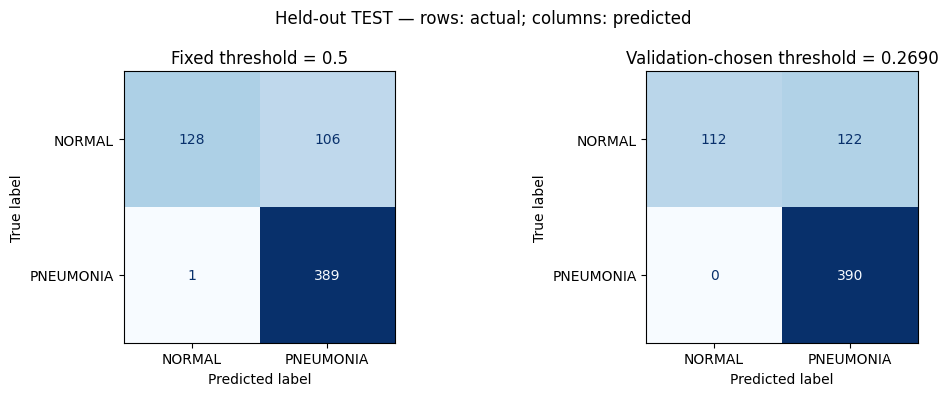

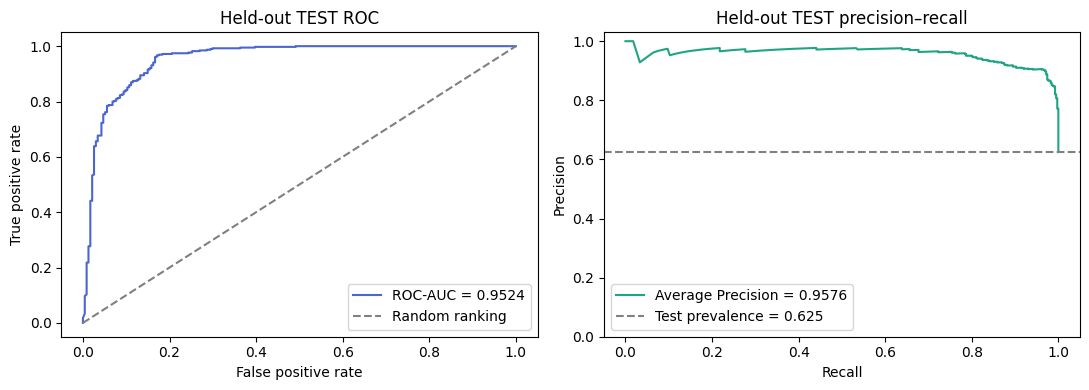

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve

if not RUN_FINAL_TEST:
    print("Held-out test plots were not generated because final evaluation is disabled.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, threshold, title in [
        (axes[0], 0.5, "Fixed threshold = 0.5"),
        (axes[1], chosen_threshold, f"Validation-chosen threshold = {chosen_threshold:.4f}"),
    ]:
        cm = confusion_matrix(y_test, (test_scores >= threshold).astype(int), labels=[0, 1])
        ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
        ax.set_title(title)
        ax.grid(False)
    fig.suptitle("Held-out TEST — rows: actual; columns: predicted")
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / "test_confusion_matrices.png", dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    fpr, tpr, _ = roc_curve(y_test, test_scores)
    t_precision, t_recall, _ = precision_recall_curve(y_test, test_scores)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(fpr, tpr, color="#4b65d1", label=f"ROC-AUC = {test_selected['roc_auc']:.4f}")
    axes[0].plot([0, 1], [0, 1], "--", color="gray", label="Random ranking")
    axes[0].set(title="Held-out TEST ROC", xlabel="False positive rate", ylabel="True positive rate")
    axes[0].legend()
    axes[1].plot(t_recall, t_precision, color="#20a486", label=f"Average Precision = {test_selected['average_precision']:.4f}")
    axes[1].axhline(y_test.mean(), ls="--", color="gray", label=f"Test prevalence = {y_test.mean():.3f}")
    axes[1].set(title="Held-out TEST precision–recall", xlabel="Recall", ylabel="Precision", ylim=(0, 1.03))
    axes[1].legend()
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / "test_roc_pr.png", dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)

## Step 15 — Generate a README from the measured run

The README is assembled from the observed dataset counts, exclusions, configuration, metrics, figures, and limitations. It is deliberately generated after execution so that values are tied to the specific run rather than entered manually.

The final `My interpretation` section is reserved for the experiment author. It should explain the model and configuration choices, the behavior seen in the learning curves or validation experiments, the most important errors, and the limitations of the evidence.

In [ ]:
from IPython.display import display, Markdown
import textwrap

if not RUN_FINAL_TEST:
    print("README generation is deferred until final test evaluation is complete.")
else:
    def markdown_table(headers, rows):
        lines = ["| " + " | ".join(headers) + " |", "| " + " | ".join(["---"] * len(headers)) + " |"]
        lines.extend("| " + " | ".join(str(value) for value in row) + " |" for row in rows)
        return "\n".join(lines)

    counts_md = markdown_table(["Split", "NORMAL", "PNEUMONIA", "Total"], [
        [name, int(row["NORMAL"]), int(row["PNEUMONIA"]), int(row["TOTAL"])]
        for name, row in final_counts.iterrows()
    ])
    metric_headers = ["Set / rule", "Threshold", "Accuracy", "Balanced acc.", "Precision", "Recall", "Specificity", "F1", "ROC-AUC", "AP"]
    metric_rows = []
    for name, values in [
        ("Validation / fixed", val_default), ("Validation / selected", val_selected),
        ("Test / fixed", test_default), ("Test / val-selected", test_selected),
        ("Test / majority baseline", majority_metrics),
    ]:
        metric_rows.append([name] + [f"{values[key]:.4f}" for key in
            ["threshold", "accuracy", "balanced_accuracy", "precision", "recall_sensitivity", "specificity", "f1", "roc_auc", "average_precision"]])
    metrics_md = markdown_table(metric_headers, metric_rows)

    exclusion_lines = "\n".join(f"- {reason}: {count}" for reason, count in audit_summary["exclusions_by_reason"].items()) or "- None."
    accuracy_delta_pp = 100.0 * (test_selected["accuracy"] - majority_metrics["accuracy"])

    report_md = f"""# Problem Set 01 - Chest X-ray CNN

## Status
Measured results from run `{RUN_ID}`. This is an educational experiment, not a clinical diagnostic system.
The custom CNN is trained from scratch; no pretrained weights or external training images are used.

## Task and data
Binary classification: **NORMAL = 0**, **PNEUMONIA = 1** (positive class).
The assignment describes pediatric chest X-rays, ages 1-5, from a single hospital setting.
Provided dataset: https://drive.google.com/file/d/1219EeGE1XTJVXYaulynJSa3BXGsbNCLx/view?usp=sharing
The assignment states 5,863 images; this run found **{audit_summary['candidate_images']} candidate images**, **{audit_summary['readable_images']} readable supported images**, and **{audit_summary['invalid_images']} unreadable/unsupported images**.
Counts are measured, not forced to match the assignment text.

## Approach and methodology
1. Audit JPEG/8-bit PNG decoding and grayscale pixel SHA-256 hashes. Ignore hidden files. Stop on contradictory labels for identical images.
2. Pool original `train` and `val` as development data; this intentionally replaces the original validation split to obtain a more useful holdout size.
3. Remove development images identical to readable original test images; conservatively remove development filename-hint groups also seen in test; deduplicate development pixels.
4. Use the first seed-fixed `StratifiedGroupKFold` fold for validation, with {N_SPLITS} folds (one train/validation split, not full cross-validation). Actual validation fraction: **{len(val_df) / len(dev):.2%}** of cleaned development data.
5. Keep all **{len(test_df)} readable original test images** held out.
6. Read grayscale, resize to **{IMAGE_SIZE[0]} x {IMAGE_SIZE[1]}**, bilinear with antialiasing. Feed float32 0-255 pixels; normalization is inside the saved model.
7. Training-only mild rotation/translation/zoom; no flips. Four blocks with two Conv2D/BatchNorm/ReLU layers each and max pooling; global average pooling, dense layer, dropout and sigmoid output.
8. Use binary cross-entropy, Adam, training-only class weights, L2, early stopping, LR reduction, and the best **validation Keras PR-AUC** checkpoint.
9. Select the positive-class F1-maximizing threshold on validation only (ties choose the largest threshold). Freeze model hash, preprocessing, label mapping and threshold before final test.
10. Report final test once for the selected model, with both the fixed 0.5 threshold and validation-selected threshold. The majority baseline always predicts the training majority class, **{CLASS_NAMES[majority_label]}**.

### Important split limitations
Filename groups (`person...`, `IM-...`, `NORMAL2-IM-...`) are unverified patient/study hints, not ground-truth patient IDs.
No detected exact-hash or inferred-group overlap remains across final splits, but **true patient-level independence is not proven**.
Hints may over-group unrelated images; unknown identities and near-duplicates may remain. Use validated patient IDs if available.
Test content/filenames were used for pre-training integrity checks, not test-performance-driven model/threshold selection.

Development exclusions ({audit_summary['excluded_development_images']} total):
{exclusion_lines}

### Final split counts
{counts_md}

## Configuration and reproducibility
- Seed: `{SEED}`; image size: `{IMAGE_SIZE}`; batch size: `{BATCH_SIZE}`.
- Conv filters: `{FILTERS}`; dense units: `{DENSE_UNITS}`; dropout: `{DROPOUT}`; L2: `{L2_STRENGTH}`.
- Initial learning rate: `{LEARNING_RATE}`; maximum epochs: `{EPOCHS}`; completed: **{len(history_df)}**.
- Best checkpoint epoch, one-based: **{best_epoch}**.
- Training time on this run: **{training_seconds / 60:.1f} minutes**.
- Parameters: **{model.count_params():,}**.
- Class weights: `{class_weight}`.
- Model SHA-256: `{frozen_config['model_sha256']}`.
- Manifests, split hashes, environment versions, hyperparameters and epoch history are in `results/`.

## Measured findings
All headline precision/recall/F1 metrics use **PNEUMONIA as positive**.

{metrics_md}

At the validation-selected threshold **{chosen_threshold:.6f}**, the final test confusion counts are:
- **TN = {test_selected['tn']}**, **FP = {test_selected['fp']}**, **FN = {test_selected['fn']}**, **TP = {test_selected['tp']}**.
- Accuracy difference versus the training-majority baseline: **{accuracy_delta_pp:+.2f} percentage points**.

### Figures
![Split counts and training image sizes](results/data_overview.png)
![Training and validation curves](results/training_curves.png)
![Validation threshold selection](results/validation_threshold.png)
![Test confusion matrices](results/test_confusion_matrices.png)
![Test ROC and precision-recall](results/test_roc_pr.png)

### Interpretation of the measured run
The from-scratch CNN was retained as a transparent baseline rather than presented as a tuned optimum. The architecture is compact enough for a Colab experiment while still providing four stages of learned spatial features. Model checkpoint selection and threshold selection used validation data only.

The selected validation threshold of {chosen_threshold:.4f} produced perfect pneumonia recall on the held-out test set, but also produced {test_selected['fp']} false positives among {int(test_df['label'].eq(0).sum())} NORMAL images. At the fixed threshold of 0.5, specificity improved from {test_selected['specificity']:.4f} to {test_default['specificity']:.4f} and accuracy improved from {test_selected['accuracy']:.4f} to {test_default['accuracy']:.4f}, while {test_default['fn']} pneumonia case became a false negative. This trade-off is more important than accuracy alone for interpreting the result.

The validation AP of {val_selected['average_precision']:.4f} and test AP of {test_selected['average_precision']:.4f} indicate strong score ranking, but the lower test operating-point performance shows a meaningful generalization gap. Only one configuration was run, so the experiment does not establish that this architecture is optimal.

## Limitations and responsible interpretation
- Limited pediatric/single-source data.
- Filename hints and exact pixel hashes do not establish true patient independence.

## Files and running
- `train_cnn.ipynb`: notebook for training and evaluation.
- `inference_config.json`: frozen class mapping, preprocessing, threshold and checkpoint hash.
- `best_cnn.keras`: saved model, retained in the external Drive run directory rather than committed to this repository.

The model hash in `inference_config.json` identifies the checkpoint used for the reported metrics. `predict.py` requires that checkpoint and the matching configuration from the same run.
"""
    report_md = textwrap.dedent(report_md).strip() + "\n"
    (RUN_DIR / "README.md").write_text(report_md, encoding="utf-8")
    display(Markdown(report_md))
    print("Generated README:", RUN_DIR / "README.md")

## Step 16 — Create a small results archive for the repository

The archive contains the generated README, inference configuration, and compact result files. It intentionally excludes the dataset, raw X-rays, and model weights. The notebook itself is downloaded separately from Colab because the current runtime filesystem is not part of this archive.

When enabled, the cell stores the archive on Drive and can also initiate a browser download. The source package and the extracted result files are intended to be combined in the repository.

In [ ]:
import zipfile

if not RUN_FINAL_TEST:
    print("Results archive skipped because final test evaluation is disabled.")
else:
    DOWNLOAD_RESULTS = True  # Enable browser download of the compact results archive.
    GITHUB_RESULTS_ZIP = DRIVE_OUTPUT_BASE / f"problem01_results_{RUN_ID}.zip"
    with zipfile.ZipFile(GITHUB_RESULTS_ZIP, "w", compression=zipfile.ZIP_DEFLATED) as archive:
        archive.write(RUN_DIR / "README.md", "problem_01_chest_xray/README.md")
        archive.write(INFERENCE_CONFIG_PATH, "problem_01_chest_xray/inference_config.json")
        for path in sorted(RESULTS_DIR.iterdir()):
            if path.is_file() and path.suffix.lower() in {".csv", ".json", ".txt", ".png"}:
                archive.write(path, "problem_01_chest_xray/results/" + path.name)
    print("Results archive:", GITHUB_RESULTS_ZIP)
    print("Model (excluded from archive):", MODEL_PATH)
    print("Inference configuration:", INFERENCE_CONFIG_PATH)
    print("Notebook and predict.py remain part of the source package.")
    if DOWNLOAD_RESULTS:
        from google.colab import files
        files.download(str(GITHUB_RESULTS_ZIP))

Small GitHub results archive: /content/drive/MyDrive/problem01_outputs/problem01_results_20260905T121522Z_f27df8.zip
Model (not inside this ZIP): /content/drive/MyDrive/problem01_outputs/20260905T121522Z_f27df8/best_cnn.keras
Matching inference settings: /content/drive/MyDrive/problem01_outputs/20260905T121522Z_f27df8/inference_config.json
Notebook + predict.py come from the source package; merge the result ZIP into it.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Step 17 — Optional inference on an uploaded image

When enabled, this cell loads a saved run and applies the preprocessing and threshold recorded in that run's inference configuration. The displayed class and pneumonia score are model outputs, not medical diagnoses; a score of 0.80 is not an assertion of 80% disease probability.

A new Colab session requires only the Drive mount and this cell, provided `SAVED_RUN_DIR` identifies a completed run containing the matching model and configuration. The inference path is independent of the training data and intermediate notebook variables.

In [ ]:
RUN_UPLOAD_DEMO = False  # Enable to run inference on uploaded images.
SAVED_RUN_DIR = None     # None uses this session's RUN_DIR; otherwise provide a saved Drive run.

if not RUN_UPLOAD_DEMO:
    print("Optional upload inference is disabled.")
else:
    import io
    import json
    import hashlib
    from pathlib import Path
    import numpy as np
    import pandas as pd
    import tensorflow as tf
    import matplotlib.pyplot as plt
    from PIL import Image
    from google.colab import files
    from IPython.display import display

    saved_root = Path(SAVED_RUN_DIR) if SAVED_RUN_DIR else globals().get("RUN_DIR")
    if saved_root is None:
        raise ValueError("Mount Drive and provide SAVED_RUN_DIR for a completed training run.")
    saved_root = Path(saved_root)
    saved_model_path = saved_root / "best_cnn.keras"
    saved_config_path = saved_root / "inference_config.json"
    config = json.loads(saved_config_path.read_text(encoding="utf-8"))
    digest = hashlib.sha256()
    with saved_model_path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    if digest.hexdigest() != config["model_sha256"]:
        raise ValueError("Model/configuration mismatch: both files must come from the same run.")
    predictor = tf.keras.models.load_model(saved_model_path, compile=False)
    uploaded = files.upload()
    rows = []
    for filename, content in uploaded.items():
        image = tf.io.decode_image(content, channels=1, expand_animations=False)
        image.set_shape([None, None, 1])
        image = tf.image.resize(image, config["image_size"], method="bilinear", antialias=True)
        image = tf.cast(image, tf.float32)  # Keep 0–255; the saved model performs rescaling.
        score = float(predictor(image[None, ...], training=False).numpy().reshape(-1)[0])
        threshold = float(config["threshold"])
        predicted_class = config["class_mapping"][str(int(score >= threshold))]
        rows.append({"image": filename, "model_class": predicted_class,
                     "pneumonia_score": score, "threshold": threshold})
        with Image.open(io.BytesIO(content)) as preview:
            fig, ax = plt.subplots(figsize=(4, 4))
            ax.imshow(preview.convert("L"), cmap="gray")
            ax.set_title(f"Model: {predicted_class} | score={score:.4f}")
            ax.axis("off")
            plt.show()
            plt.close(fig)
    display(pd.DataFrame(rows))
    print("Model output only; this is not a diagnosis or calibrated disease probability.")